# Laborator 7 - Rezolvarea unor probleme de clasificare prin metode de învățare automată


Dezvoltarea sistemelor care învaţă singure. Probleme de tip clasificare rezolvate cu ajutorul rețeleleor neuronale artificiale (Artificial Neural Networks - ANN). Evaluareaa performanței acestor metode.


## 💡 Probleme
Retea sociala: ce fel de poze ai postat?
(TEMA) Tocmai ti-ai inceput prima ta zi de munca ca si software developer la Facebook in echipa care se ocupa cu partea de continut a platformei. Echipa de analisti a observat ca foarte multe persoane folosesc filtre peste pozele lor, asadar in speranta de a promova continut mai putin editat, si poze cat mai reale, doresc sa implementeze o noua functionalite in care sa arate utilizatorilor daca o poza a fost sau nu editata. Pentru a testa aceasta idee, si pentru a vedea daca utlizatorilor li s-ar parea folositoare o astfel de functionalitate, au decis sa testeze ideea pe pozele care au filtre sepia. Primul task al tau este sa implementezi un algoritm de clasificare a pozelor care sa ne spuna daca o poza are sau nu adaugat filtru sepia. Team leaderul echipei de ML iti propune urmatorul plan de lucru

* devoltarea, antrenarea si testarea unui clasificator bazat pe retele neuronale folosind date mai simple, de tip caracteristici numerice - de ex datele cu irisi) - Lucky you! Go to DEMO! 🍀
* devoltarea, antrenarea si testarea unui clasificator bazat pe retele neuronale folosind date mai complexe, de tip imagine - de ex baza de date cu cifre, pentru fiecare exemplu se va considera matricea de pixeli) - Lucky you! Go to DEMO! 🍀
* crearea unei baze cu imagini (cu si fara filtru sepia) si etichetele corespunzatoare - Let’s get down to business! 🚀
* antrenarea si testarea clasificatorului (bazat pe retele neuronale artificiale – tool sau ANN-ul dezvoltat) pentru clasificarea imaginilor cu si fara filtru - It's time to hustle! 💪


## 📝 Cerinte
Specificaţi, proiectaţi, implementaţi si testati cate un algoritm de clasificare bazat pe retele neuronale artificiale (ANN sau CNN). Verificati influenta (hyper)parametrilor asupra calitatii clasificatorului antrenat.

In [ ]:
import shutil
shutil.rmtree('Dataset - final')
shutil.rmtree('Data - final')
shutil.rmtree('Dataset - test')
shutil.rmtree('Dataset')




DATA SET ORIGINAL - 81 de imagini de 224x224

https://www.kaggle.com/datasets/abhinavnayak/catsvdogs-transformed?resource=download

Image 1.png saved as 1_sepia.png
Image 10.png saved as 10_sepia.png
Image 11.png saved as 11_sepia.png
Image 12.png saved as 12_sepia.png
Image 13.png saved as 13_sepia.png
Image 14.png saved as 14_sepia.png
Image 15.png saved as 15_sepia.png
Image 16.png saved as 16_sepia.png
Image 17.png saved as 17_sepia.png
Image 18.png saved as 18_sepia.png
Image 19.png saved as 19_sepia.png
Image 2.png saved as 2_sepia.png
Image 20.png saved as 20_sepia.png
Image 21.png saved as 21_sepia.png
Image 22.png saved as 22_sepia.png
Image 23.png saved as 23_sepia.png
Image 24.png saved as 24_sepia.png
Image 25.png saved as 25_sepia.png
Image 26.png saved as 26_sepia.png
Image 27.png saved as 27_sepia.png
Image 28.png saved as 28_sepia.png
Image 29.png saved as 29_sepia.png
Image 3.png saved as 3_sepia.png
Image 30.png saved as 30_sepia.png
Image 31.png saved as 31_sepia.png
Image 32.png saved as 32_sepia.png
Image 33.png saved as 33_sepia.png
Image 34.png saved as 34_sepia.png
Image 35.png saved as 35_s

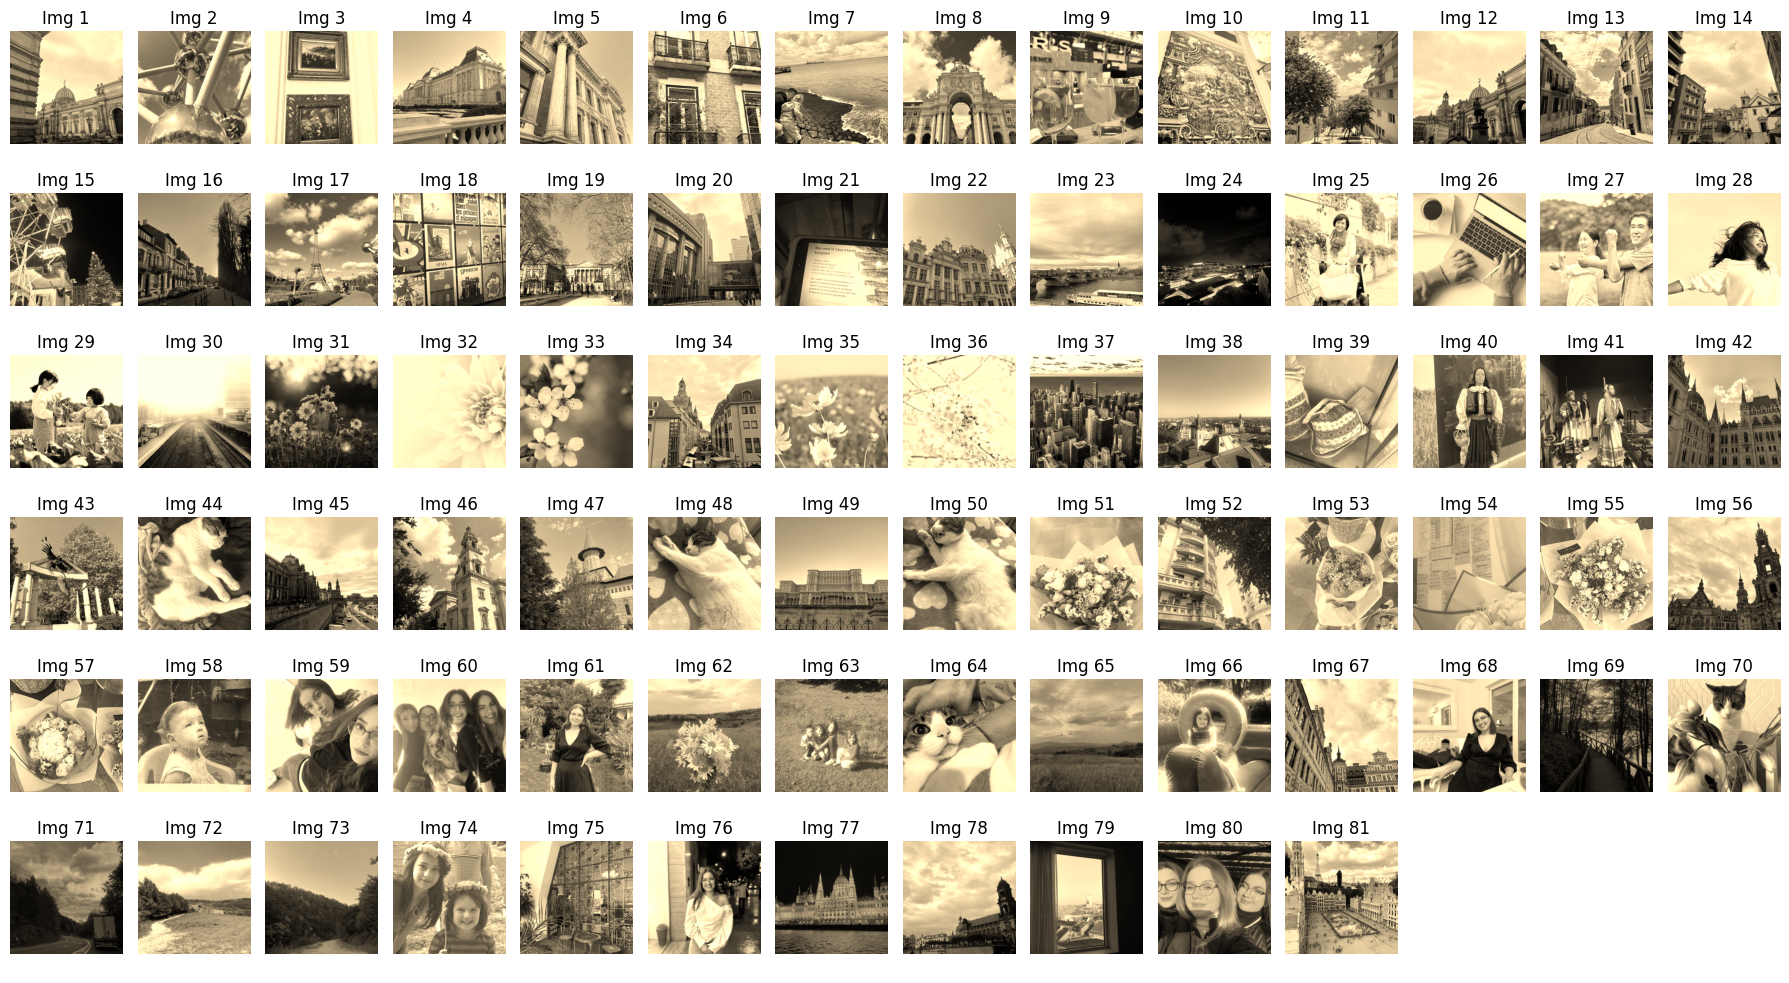

Image cat193.jpg saved as cat193_sepia.jpg
Image cat194.jpg saved as cat194_sepia.jpg
Image cat195.jpg saved as cat195_sepia.jpg
Image cat196.jpg saved as cat196_sepia.jpg
Image cat222.jpg saved as cat222_sepia.jpg
Image cat223.jpg saved as cat223_sepia.jpg
Image cat224.jpg saved as cat224_sepia.jpg
Image cat225.jpg saved as cat225_sepia.jpg
Image cat226.jpg saved as cat226_sepia.jpg
Image cat227.jpg saved as cat227_sepia.jpg
Image cat23.jpg saved as cat23_sepia.jpg
Image cat24.jpg saved as cat24_sepia.jpg
Image cat25.jpg saved as cat25_sepia.jpg
Image cat26.jpg saved as cat26_sepia.jpg
Image cat261.jpg saved as cat261_sepia.jpg
Image cat262.jpg saved as cat262_sepia.jpg
Image cat263.jpg saved as cat263_sepia.jpg
Image cat264.jpg saved as cat264_sepia.jpg
Image cat265.jpg saved as cat265_sepia.jpg
Image cat266.jpg saved as cat266_sepia.jpg
Image cat267.jpg saved as cat267_sepia.jpg
Image cat27.jpg saved as cat27_sepia.jpg
Image cat28.jpg saved as cat28_sepia.jpg
Image cat29.jpg saved a

NotADirectoryError: [Errno 20] Not a directory: 'Data - final'

In [3]:
import numpy as np
import os
from PIL import Image
from tensorflow.keras.preprocessing import image
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

# apply sepia filter to the image
def apply_sepia(image):
    image = image.convert('RGB')
    width, height = image.size
    pixels = image.load()
    for py in range(height):
        for px in range(width):
            r, g, b = image.getpixel((px, py))
            tr = min(255, int(0.393 * r + 0.769 * g + 0.189 * b))
            tg = min(255, int(0.349 * r + 0.686 * g + 0.168 * b))
            tb = min(255, int(0.272 * r + 0.534 * g + 0.131 * b))
            pixels[px, py] = (tr, tg, tb)
    return image

# display sepia images in a grid
def plot_images_in_grid(images, grid_size=(6, 14)):
    fig, axes = plt.subplots(grid_size[0], grid_size[1], figsize=(18, 10))
    axes = axes.flatten()
    for i, img in enumerate(images):
        axes[i].imshow(img)
        axes[i].axis('off')
        axes[i].set_title(f"Img {i+1}")
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
    plt.tight_layout()
    plt.show()

# generate and save sepia images
def process_images_in_folder(folder_path):
    if not os.path.exists(folder_path):
        print(f"Folder '{folder_path}' does not exist.")
        return

    images = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))])
    processed_images = []

    for filename in images:
        file_path = os.path.join(folder_path, filename)
        img = Image.open(file_path)
        sepia = apply_sepia(img)
        sepia_name = f"{os.path.splitext(filename)[0]}_sepia{os.path.splitext(filename)[1]}"
        sepia_path = os.path.join(folder_path, sepia_name)
        sepia.save(sepia_path)
        print(f"Image {filename} saved as {sepia_name}")
        processed_images.append(sepia)

    plot_images_in_grid(processed_images)

# load and label images for training
def load_images(folder, label_type='auto', target_size=(224, 224)):
    images = []
    labels = []
    for filename in os.listdir(folder):
        if filename.lower().endswith(('jpg', 'jpeg', 'png')):  # only process image files
            img_path = os.path.join(folder, filename)
            img = image.load_img(img_path, target_size=target_size)
            img_array = image.img_to_array(img) / 255.0  # Normalize image
            images.append(img_array)

            # assign label based on the filename
            if '_sepia' in filename:  # Check if the filename indicates sepia
                labels.append(1)  # sepia images get label 1
            else:
                labels.append(0)  # normal images get label 0

    return images, labels


# process sepia generation from images in 'Data - final'
process_images_in_folder('Dataset - final')  # create sepia images and show them
process_images_in_folder_without_display('Dataset')

# load normal images from 'Dataset' - > KEG
normal_images, normal_labels = load_images('Dataset', label_type='auto')

# load mixed images (normal and sepia) from 'Data - final'
mixed_images, mixed_labels = load_images('Data - final', label_type='auto')

# combine all data
all_images = np.array(normal_images + mixed_images)
all_labels = to_categorical(normal_labels + mixed_labels, num_classes=2)


In [2]:
# generate and save sepia images from a specific folder, without displaying them
def process_images_in_folder_without_display(folder_path):
    if not os.path.exists(folder_path):
        print(f"Folder '{folder_path}' does not exist.")
        return

    images = sorted([f for f in os.listdir(folder_path) if f.lower().endswith(('jpg', 'jpeg', 'png'))])
    processed_images = []

    for filename in images:
        file_path = os.path.join(folder_path, filename)
        img = Image.open(file_path)
        sepia = apply_sepia(img)
        sepia_name = f"{os.path.splitext(filename)[0]}_sepia{os.path.splitext(filename)[1]}"
        sepia_path = os.path.join(folder_path, sepia_name)
        sepia.save(sepia_path)
        print(f"Image {filename} saved as {sepia_name}")
        processed_images.append(sepia)


### 🔹 Artificial Neural Networks (ANN)

**Ce sunt?**
Artificial Neural Networks sunt modele inspirate de modul în care funcționează creierul uman. Ele sunt formate din **neuroni artificiali** organizați în **straturi**:

* **Input layer** – primește datele (ex: pixelii unei imagini).
* **Hidden layers** – procesează datele prin conexiuni ponderate.
* **Output layer** – returnează rezultatul (ex: sepia sau normal).

**Cum funcționează?**

1. Fiecare neuron primește input (ex: pixeli), îl înmulțește cu un **weight** și adaugă un **bias**.
2. Aplică o **funcție de activare** (ex: ReLU sau softmax).
3. Semnalul rezultat merge spre următorul strat.
4. La final, comparăm ieșirea cu valoarea reală → calculăm **loss** → ajustăm weights prin **backpropagation**.


### 🔹 Adam Optimizer

**Ce este?**
**Adam (Adaptive Moment Estimation)** este un algoritm de optimizare folosit pentru a actualiza weights-ul în timpul antrenării. E foarte popular pentru că:

* combină avantajele **SGD** (Stochastic Gradient Descent) cu cele ale algoritmilor **RMSProp** și **Momentum**.
* e **rapid**, **eficient**, și se descurcă bine pe seturi mari de date.

**Cum funcționează (pe scurt)?**

* Păstrează două valori pentru fiecare weight:

  * media gradientului (**momentum** – cât de mare și constant e gradientul);
  * media pătratelor gradientului (**adaptare** – ca să nu fie prea mari update-urile).
* Ajustează fiecare weight în funcție de aceste două medii, deci învață mai stabil și mai eficient.

**Parametrii principali:**

* `learning rate` – cât de repede se învață (default: 0.001).
* `beta1` și `beta2` – controlează cât de mult ținem cont de media gradientului (default: 0.9 și 0.999).

antrenarea unui model si testarea lui pentru clasificarea imaginilor normale vs sepia
cu ANN (tool)

Epoch 1/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 8s 391ms/step - accuracy: 0.4841 - loss: 36.4983 - val_accuracy: 0.5532 - val_loss: 13.0057
Epoch 2/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 353ms/step - accuracy: 0.4809 - loss: 14.4317 - val_accuracy: 0.4681 - val_loss: 3.9667
Epoch 3/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 440ms/step - accuracy: 0.5311 - loss: 3.7233 - val_accuracy: 0.4681 - val_loss: 7.6099
Epoch 4/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 356ms/step - accuracy: 0.5270 - loss: 7.7043 - val_accuracy: 0.5745 - val_loss: 5.8645
Epoch 5/5
14/14 ━━━━━━━━━━━━━━━━━━━━ 6s 457ms/step - accuracy: 0.5999 - loss: 4.1190 - val_accuracy: 0.5319 - val_loss: 3.2523
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step - accuracy: 0.4888 - loss: 3.7413

Test Accuracy: 0.53


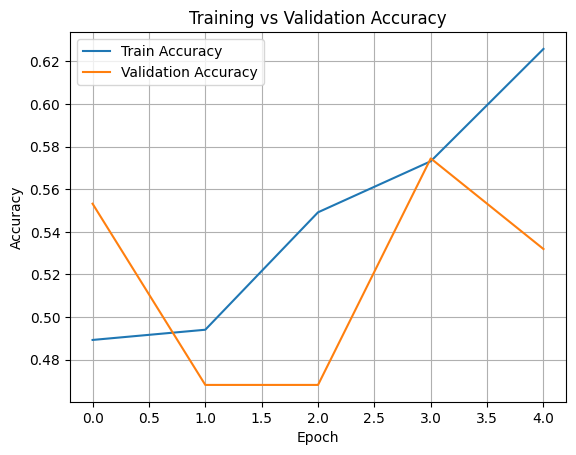

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

# the model does not learn from the filename
# it classifies based on image pixel data only

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(all_images, all_labels, test_size=0.2, random_state=42)

# Define the ANN model architecture
model = Sequential([
    Flatten(input_shape=(224, 224, 3)),     # Flatten the 3D image into a 1D vector
    Dense(128, activation='relu'),          # First hidden layer with ReLU activation
    Dense(64, activation='relu'),           # Second hidden layer with ReLU activation
    Dense(2, activation='softmax')          # Output layer for 2 classes: normal and sepia
])

# Compile the model with optimizer, loss function, and evaluation metric
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Train the model using training data
history = model.fit(X_train, y_train, epochs=5, batch_size=32, validation_split=0.1)

# Evaluate the model performance on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_accuracy:.2f}")

# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()



testam pe imagini noi

Image 1.png saved as 1_sepia.png
Image 10.png saved as 10_sepia.png
Image 11.png saved as 11_sepia.png
Image 12.png saved as 12_sepia.png
Image 2.png saved as 2_sepia.png
Image 3.png saved as 3_sepia.png
Image 4.png saved as 4_sepia.png
Image 5.png saved as 5_sepia.png
Image 6.png saved as 6_sepia.png
Image 7.png saved as 7_sepia.png
Image 8.png saved as 8_sepia.png
Image 9.png saved as 9_sepia.png


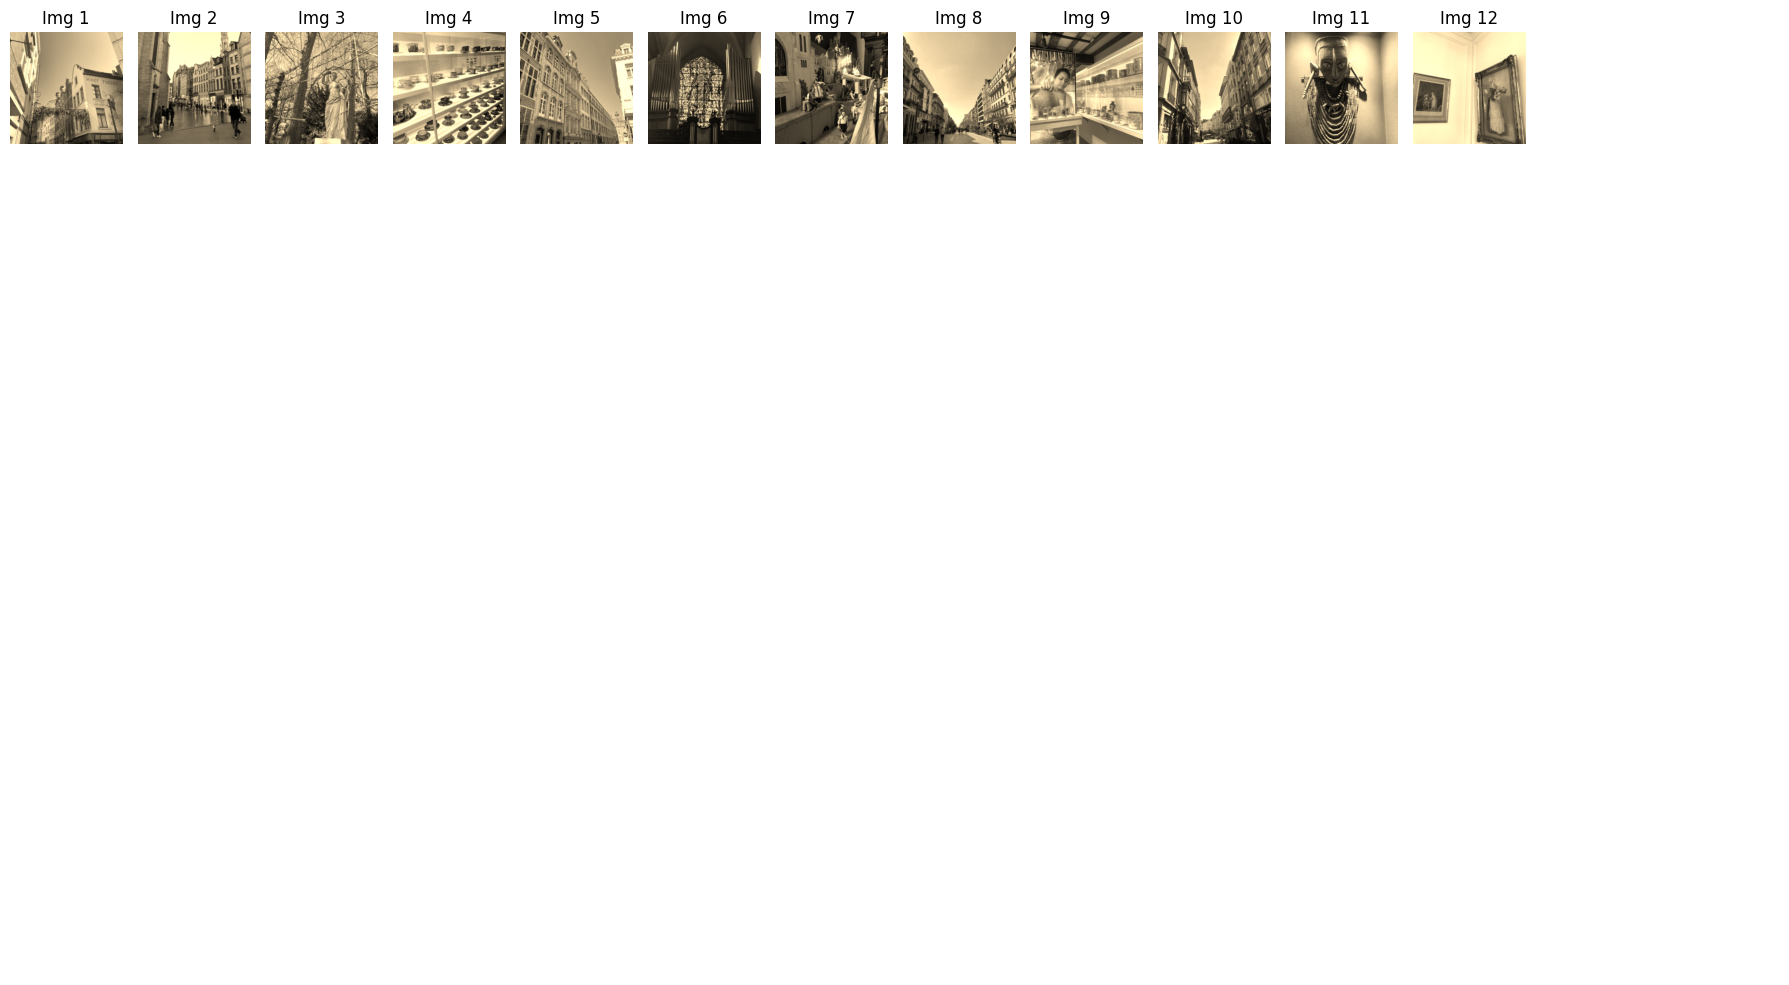

In [ ]:
process_images_in_folder('Dataset - test')

In [ ]:
# Load and label images from 'Dataset - test'
test_images, test_labels = load_images('Dataset - test', label_type='auto')

# Convert to numpy arrays
test_images = np.array(test_images)
test_labels = to_categorical(test_labels, num_classes=2)


In [ ]:
# Evaluate model on new test images
loss, accuracy = model.evaluate(test_images, test_labels)
print(f"\nAccuracy on 'Dataset - test': {accuracy:.2f}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - accuracy: 0.4583 - loss: 2.9384

Accuracy on 'Dataset - test': 0.46


In [ ]:
import os
import numpy as np

# Get list of filenames (sorted to match the load order)
filenames = sorted([f for f in os.listdir('Dataset - test') if f.lower().endswith(('jpg', 'jpeg', 'png'))])

# Predict classes
predictions = model.predict(test_images)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = np.argmax(test_labels, axis=1)

# Check prediction vs. actual filename
for i, filename in enumerate(filenames):
    predicted_label = 'sepia' if predicted_classes[i] == 1 else 'normal'
    actual_label = 'sepia' if '_sepia' in filename else 'normal'
    correct = predicted_label == actual_label
    print(f"{filename}: predicted = {predicted_label}, actual = {actual_label} --> {'✅' if correct else '❌'}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step
1.png: predicted = normal, actual = normal --> ✅
10.png: predicted = sepia, actual = normal --> ❌
10_sepia.png: predicted = normal, actual = sepia --> ❌
11.png: predicted = normal, actual = normal --> ✅
11_sepia.png: predicted = normal, actual = sepia --> ❌
12.png: predicted = normal, actual = normal --> ✅
12_sepia.png: predicted = normal, actual = sepia --> ❌
1_sepia.png: predicted = normal, actual = sepia --> ❌
2.png: predicted = normal, actual = normal --> ✅
2_sepia.png: predicted = normal, actual = sepia --> ❌
3.png: predicted = normal, actual = normal --> ✅
3_sepia.png: predicted = normal, actual = sepia --> ❌
4.png: predicted = normal, actual = normal --> ✅
4_sepia.png: predicted = normal, actual = sepia --> ❌
5.png: predicted = normal, actual = normal --> ✅
5_sepia.png: predicted = normal, actual = sepia --> ❌
6.png: predicted = normal, actual = normal --> ✅
6_sepia.png: predicted = normal, actual = sepia --> ❌
7.png: predicted = normal, ac

Pașii principali pentru ANN propriu:

* Definirea rețelei neuronale manual: Vei crea fiecare strat al rețelei (input, hidden și output) din cod propriu, folosind doar funcții matematice de bază, cum ar fi sigmoid, relu, softmax, etc. Va trebui să implementezi și procesul de backpropagation pentru ajustarea greutăților.

* Inițializarea greutăților: Vei genera greutăți aleatorii pentru fiecare conexiune între neuroni și le vei ajusta pe măsură ce modelul învață.

* Funcția de cost și optimizare: Vei alege o funcție de cost (de exemplu, categorical crossentropy) și un algoritm de optimizare (de exemplu, gradient descent).

* Implementarea unui proces de antrenare: Vei împărți setul de date în loturi și vei itera prin date pentru a antrena modelul, actualizând greutățile pe baza erorii.

### Influenta (hyper)parametrilor asupra calității clasificatorului

În învățarea automată, hiperparametrii sunt parametri care sunt setați înainte de antrenarea modelului, spre deosebire de parametrii modelului (greutăți și biasuri) care sunt ajustați în timpul antrenării.

1. Hiperparametrii pot influența semnificativ performanța modelului. Exemple de hiperparametri pentru rețelele neuronale includ:

2. Numărul de epoci (epochs): Numărul de iterații prin setul de date. Mai multe epoci pot îmbunătăți acuratețea, dar dacă sunt prea multe, modelul poate deveni supraaglomerat (overfitting).

3. Dimensiunea lotului (batch size): Numărul de exemple utilizate pentru actualizarea greutăților într-o singură iterație. Loturi mai mici pot duce la o convergență mai rapidă, dar poate fi mai instabil, pe când loturi mai mari sunt mai stabile, dar mai lente.

4. Rata de învățare (learning rate): Determină cât de mult se actualizează greutățile în timpul fiecărei iterații. O rată prea mare poate face modelul să nu învețe corect, iar una prea mică poate duce la un proces de învățare lent.

5. Numărul de neuroni din straturile ascunse: Dacă ai prea puțini neuroni, modelul poate să nu fie suficient de puternic pentru a învăța relațiile complexe dintre datele de intrare și ieșire. Dacă ai prea mulți neuroni, modelul riscă să fie supraaglomerat (overfitting).

Epoch 1/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 414ms/step - accuracy: 0.5928 - loss: 2.4992 - val_accuracy: 0.8085 - val_loss: 1.3659
Epoch 2/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 400ms/step - accuracy: 0.8545 - loss: 0.8287 - val_accuracy: 0.6383 - val_loss: 1.3735
Epoch 3/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 398ms/step - accuracy: 0.8186 - loss: 0.9091 - val_accuracy: 0.7234 - val_loss: 2.4611
Epoch 4/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 6s 565ms/step - accuracy: 0.7741 - loss: 1.4837 - val_accuracy: 0.7234 - val_loss: 0.9012
Epoch 5/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 4s 400ms/step - accuracy: 0.8136 - loss: 0.8291 - val_accuracy: 0.8085 - val_loss: 1.5669
Epoch 6/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 411ms/step - accuracy: 0.7676 - loss: 1.4291 - val_accuracy: 0.7234 - val_loss: 2.1870
Epoch 7/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 417ms/step - accuracy: 0.8006 - loss: 1.0916 - val_accuracy: 0.8085 - val_loss: 1.5196
Epoch 8/20
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 402ms/step - accuracy: 0.8241 - loss: 0.8424 - val_accuracy: 0.7872 - val_loss:

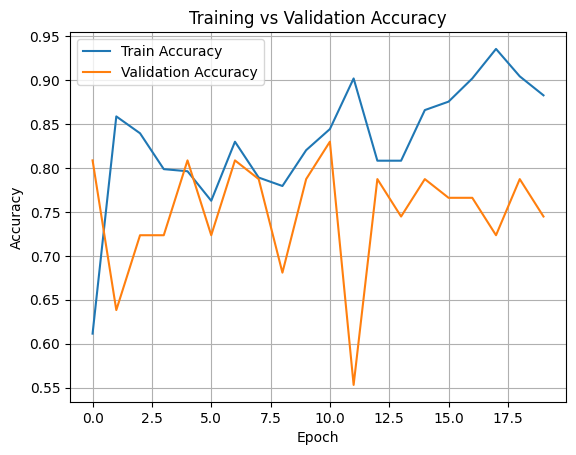

In [ ]:
# Train the model using training data
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.1)

# Evaluate the model performance on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_accuracy:.2f}")

# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

Epoch 1/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 8s 301ms/step - accuracy: 0.8252 - loss: 0.6231 - val_accuracy: 0.7234 - val_loss: 2.1672
Epoch 2/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 12s 352ms/step - accuracy: 0.7509 - loss: 1.2752 - val_accuracy: 0.7447 - val_loss: 0.6059
Epoch 3/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 9s 345ms/step - accuracy: 0.8990 - loss: 0.3957 - val_accuracy: 0.7447 - val_loss: 0.6866
Epoch 4/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 369ms/step - accuracy: 0.8271 - loss: 0.6426 - val_accuracy: 0.7021 - val_loss: 2.2967
Epoch 5/5
27/27 ━━━━━━━━━━━━━━━━━━━━ 10s 368ms/step - accuracy: 0.6910 - loss: 1.4754 - val_accuracy: 0.5532 - val_loss: 2.0434
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step - accuracy: 0.5304 - loss: 2.7567

Test Accuracy: 0.56


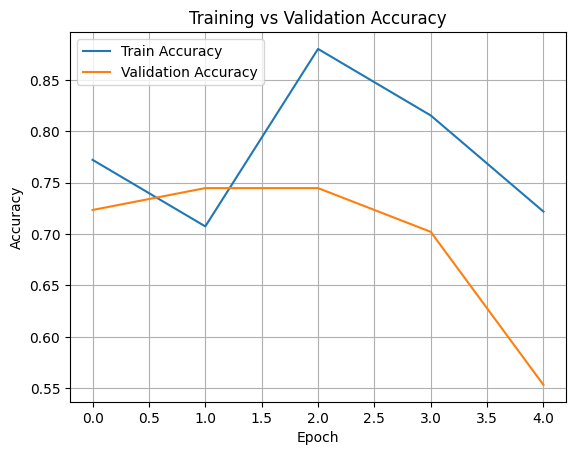

In [ ]:
# Train the model using training data
history = model.fit(X_train, y_train, epochs=5, batch_size=16, validation_split=0.1)

# Evaluate the model performance on the test set
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"\nTest Accuracy: {test_accuracy:.2f}")

# Plot training and validation accuracy over epochs
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid()
plt.show()

Pe baza experimentelor efectuate, se poate observa că numărul de epoci, dimensiunea lotului și alți hiperparametri influențează semnificativ performanța modelului de învățare automată!!!!! 🙂

## Implementare ANN

In [ ]:
import numpy as np

class MyANN:
    # epochs!!!
    def __init__(self, hidden_size=128, learning_rate=0.01, epochs=1000, random_state=42):
        # initialize hyperparameters
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.random_state = random_state
        self.is_fitted = False

    def _initialize_parameters(self, input_size, output_size):
        # initialize weights and biases using a small random distribution
        np.random.seed(self.random_state)
        self.W1 = np.random.randn(self.hidden_size, input_size) * 0.01
        self.b1 = np.zeros((self.hidden_size, 1))
        self.W2 = np.random.randn(output_size, self.hidden_size) * 0.01
        self.b2 = np.zeros((output_size, 1))

    def _relu(self, Z):
        # apply relu activation function
        return np.maximum(0, Z)

    def _softmax(self, Z):
        # apply softmax activation function for multi-class output
        expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
        return expZ / expZ.sum(axis=0, keepdims=True)

    def _forward(self, X):
        # forward propagation
        Z1 = self.W1.dot(X.T) + self.b1
        A1 = self._relu(Z1)
        Z2 = self.W2.dot(A1) + self.b2
        A2 = self._softmax(Z2)
        return A1, A2

    def _compute_loss(self, A2, Y):
        # compute cross-entropy loss
        m = Y.shape[0]
        log_probs = -np.log(A2[Y, np.arange(m)])
        loss = np.sum(log_probs) / m
        return loss

    def _backward(self, X, Y, A1, A2):
        # backward propagation
        m = X.shape[0]
        Y_onehot = np.zeros_like(A2)
        Y_onehot[Y, np.arange(m)] = 1

        dZ2 = A2 - Y_onehot
        dW2 = (1/m) * dZ2.dot(A1.T)
        db2 = (1/m) * np.sum(dZ2, axis=1, keepdims=True)

        dA1 = self.W2.T.dot(dZ2)
        dZ1 = dA1 * (A1 > 0)  # derivative of relu
        dW1 = (1/m) * dZ1.dot(X)
        db1 = (1/m) * np.sum(dZ1, axis=1, keepdims=True)

        # update weights and biases
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

    def fit(self, X, y):
        # train the model using the training data
        input_size = X.shape[1]
        output_size = np.max(y) + 1  # assume labels are 0, 1, ..., n

        self._initialize_parameters(input_size, output_size)

        for epoch in range(self.epochs):
            A1, A2 = self._forward(X)
            loss = self._compute_loss(A2, y)
            self._backward(X, y, A1, A2)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}/{self.epochs} - Loss: {loss:.4f}")

        self.is_fitted = True
        return self

    def predict(self, X):
        # return predicted class labels
        if not self.is_fitted:
            raise ValueError("model is not trained yet. call fit() first.")
        _, A2 = self._forward(X)
        return np.argmax(A2, axis=0)

    def predict_proba(self, X):
        # return class probabilities
        if not self.is_fitted:
            raise ValueError("model is not trained yet. call fit() first.")
        _, A2 = self._forward(X)
        return A2.T

    def score(self, X, y):
        # return accuracy of predictions
        preds = self.predict(X)
        return np.mean(preds == y)


In [ ]:
import os
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# load and preprocess images
def load_images_from_folder(folder, image_size=(64, 64)):
    X = []
    y = []
    for filename in os.listdir(folder):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            # assign label 1 if 'sepia' is in the filename, otherwise 0
            label = 1 if 'sepia' in filename.lower() else 0
            img_path = os.path.join(folder, filename)
            # open the image, convert to RGB, resize, normalize to [0,1]
            img = Image.open(img_path).convert('RGB').resize(image_size)
            img_array = np.array(img).astype(np.float32) / 255.0
            # flatten the image into a 1D array
            X.append(img_array.flatten())
            y.append(label)
    return np.array(X), np.array(y)

X, y = load_images_from_folder('Dataset', image_size=(64, 64))
print(f"Loaded {len(X)} images.")

# split the dataset into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


Loaded 580 images.


In [ ]:
# ANN
clf = MyANN(hidden_size=256, learning_rate=0.1, epochs=1000)  # adjusted for high-dim input

# train the model
clf.fit(X_train, y_train)

# predict on test set
y_pred = clf.predict(X_test)

# evaluate model
acc = clf.score(X_test, y_test)
print(f"\nTest Accuracy: {acc:.2f}")

# classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Epoch 0/1000 - Loss: 0.6987
Epoch 100/1000 - Loss: 0.6575
Epoch 200/1000 - Loss: 0.6955
Epoch 300/1000 - Loss: 0.6962
Epoch 400/1000 - Loss: 0.6934
Epoch 500/1000 - Loss: 0.6912
Epoch 600/1000 - Loss: 0.6808
Epoch 700/1000 - Loss: 0.6910
Epoch 800/1000 - Loss: 0.6899
Epoch 900/1000 - Loss: 0.6926

Test Accuracy: 0.51

Classification Report:
              precision    recall  f1-score   support

           0       0.51      1.00      0.67        59
           1       0.00      0.00      0.00        57

    accuracy                           0.51       116
   macro avg       0.25      0.50      0.34       116
weighted avg       0.26      0.51      0.34       116



/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
import numpy as np
import os
from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt

# Initialize neural network
class MyANN:
    def __init__(self, hidden_size=128, learning_rate=0.01, epochs=1000, lambda_reg=0.01, random_state=42):
        self.hidden_size = hidden_size
        self.learning_rate = learning_rate
        self.epochs = epochs
        self.lambda_reg = lambda_reg  # Regularization parameter
        self.random_state = random_state
        self.is_fitted = False

    def _initialize_parameters(self, input_size, output_size):
        np.random.seed(self.random_state)
        # Xavier initialization
        self.W1 = np.random.randn(self.hidden_size, input_size) * np.sqrt(2 / input_size)
        self.b1 = np.zeros((self.hidden_size, 1))
        self.W2 = np.random.randn(output_size, self.hidden_size) * np.sqrt(2 / self.hidden_size)
        self.b2 = np.zeros((output_size, 1))

    def _leaky_relu(self, Z, alpha=0.01):
        return np.maximum(alpha * Z, Z)

    def _softmax(self, Z):
        expZ = np.exp(Z - np.max(Z, axis=0, keepdims=True))
        return expZ / expZ.sum(axis=0, keepdims=True)

    def _forward(self, X):
        Z1 = self.W1.dot(X.T) + self.b1
        A1 = self._leaky_relu(Z1)
        Z2 = self.W2.dot(A1) + self.b2
        A2 = self._softmax(Z2)
        return A1, A2

    def _compute_loss(self, A2, Y, reg_term):
        m = Y.shape[0]
        log_probs = -np.log(A2[Y, np.arange(m)])
        loss = np.sum(log_probs) / m
        # Add regularization term
        loss += reg_term
        return loss

    def _backward(self, X, Y, A1, A2):
        m = X.shape[0]
        Y_onehot = np.zeros_like(A2)
        Y_onehot[Y, np.arange(m)] = 1

        dZ2 = A2 - Y_onehot
        dW2 = (1 / m) * dZ2.dot(A1.T) + (self.lambda_reg / m) * self.W2  # L2 regularization
        db2 = (1 / m) * np.sum(dZ2, axis=1, keepdims=True)

        dA1 = self.W2.T.dot(dZ2)
        dZ1 = dA1 * (A1 > 0)  # derivative of Leaky ReLU
        dW1 = (1 / m) * dZ1.dot(X) + (self.lambda_reg / m) * self.W1  # L2 regularization
        db1 = (1 / m) * np.sum(dZ1, axis=1, keepdims=True)

        # Update weights and biases
        self.W1 -= self.learning_rate * dW1
        self.b1 -= self.learning_rate * db1
        self.W2 -= self.learning_rate * dW2
        self.b2 -= self.learning_rate * db2

    def fit(self, X, y):
        input_size = X.shape[1]
        output_size = np.max(y) + 1  # assume labels are 0, 1, ..., n
        self._initialize_parameters(input_size, output_size)

        for epoch in range(self.epochs):
            A1, A2 = self._forward(X)
            reg_term = (self.lambda_reg / 2) * (np.sum(np.square(self.W1)) + np.sum(np.square(self.W2)))
            loss = self._compute_loss(A2, y, reg_term)
            self._backward(X, y, A1, A2)

            if epoch % 100 == 0:
                print(f"Epoch {epoch}/{self.epochs} - Loss: {loss:.4f}")

        self.is_fitted = True
        return self

    def predict(self, X):
        if not self.is_fitted:
            raise ValueError("Model is not trained yet. Call fit() first.")
        _, A2 = self._forward(X)
        return np.argmax(A2, axis=0)

    def predict_proba(self, X):
        if not self.is_fitted:
            raise ValueError("Model is not trained yet. Call fit() first.")
        _, A2 = self._forward(X)
        return A2.T

    def score(self, X, y):
        preds = self.predict(X)
        return np.mean(preds == y)



In [ ]:
# Load and preprocess images
def load_images_from_folder(folder, image_size=(64, 64)):
    X = []
    y = []
    for filename in os.listdir(folder):
        if filename.endswith(('.png', '.jpg', '.jpeg')):
            label = 1 if 'sepia' in filename.lower() else 0
            img_path = os.path.join(folder, filename)
            img = Image.open(img_path).convert('RGB').resize(image_size)
            img_array = np.array(img).astype(np.float32) / 255.0
            X.append(img_array.flatten())
            y.append(label)
    return np.array(X), np.array(y)

# Load data
X, y = load_images_from_folder('Dataset', image_size=(64, 64))
print(f"Loaded {len(X)} images.")

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Create and train ANN model
clf = MyANN(hidden_size=256, learning_rate=0.01, epochs=1000, lambda_reg=0.01)
clf.fit(X_train, y_train)

# Predict and evaluate model
y_pred = clf.predict(X_test)

# Evaluate model
acc = clf.score(X_test, y_test)
print(f"\nTest Accuracy: {acc:.2f}")

# Classification report
print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Loaded 580 images.
Epoch 0/1000 - Loss: 3.4492
Epoch 100/1000 - Loss: 3.1682
Epoch 200/1000 - Loss: 3.0776
Epoch 300/1000 - Loss: 2.9928
Epoch 400/1000 - Loss: 2.9227
Epoch 500/1000 - Loss: 2.8675
Epoch 600/1000 - Loss: 2.8241
Epoch 700/1000 - Loss: 2.7998
Epoch 800/1000 - Loss: 2.7768
Epoch 900/1000 - Loss: 2.7599

Test Accuracy: 0.87

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.76      0.86        59
           1       0.80      0.98      0.88        57

    accuracy                           0.87       116
   macro avg       0.89      0.87      0.87       116
weighted avg       0.89      0.87      0.87       116



## Implementare CNN

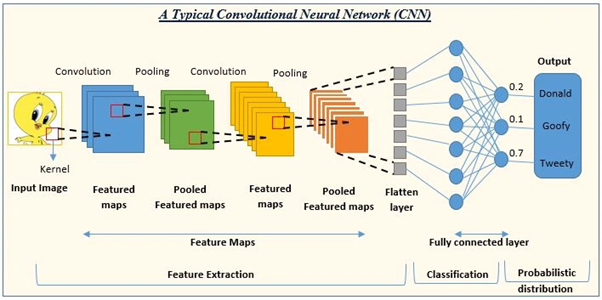

In [34]:
import os
from PIL import Image, ImageOps
import numpy as np
import random
from sklearn.preprocessing import StandardScaler
from sklearn import neural_network
from sklearn import linear_model
import matplotlib.pyplot as plt

In [51]:
import numpy as np
from scipy import signal

In [52]:
class Layer:
    def __init__(self):
        self.input = None   # stores the input of the layer
        self.output = None  # stores the output of the layer

    def forward(self, input):
        # computes the output of the layer (to be implemented in subclasses)
        pass

    def backward(self, output_gradient, learning_rate):
        # computes the gradient for the previous layer and updates parameters (to be implemented in subclasses)
        pass


In [53]:
class Convolutional(Layer):
    def __init__(self, input_shape, kernel_size, depth):
        input_depth, input_height, input_width = input_shape
        self.depth = depth  # number of output feature maps
        self.input_shape = input_shape  # shape of the input (depth, height, width)
        self.input_depth = input_depth  # number of input channels
        # shape of the output after applying the kernel (valid padding)
        self.output_shape = (depth, input_height - kernel_size + 1, input_width - kernel_size + 1)
        # shape of the kernels: one kernel per input channel, per output channel
        self.kernels_shape = (depth, input_depth, kernel_size, kernel_size)
        # randomly initialize kernels
        self.kernels = np.random.randn(*self.kernels_shape)
        # randomly initialize biases
        self.biases = np.random.randn(*self.output_shape)

    def forward(self, input):
        self.input = input  # store the input for use in backward pass
        self.output = np.copy(self.biases)  # initialize output with biases

        for i in range(self.depth):
            for j in range(self.input_depth):
                # apply 2d correlation for each input channel and sum results
                self.output[i] += signal.correlate2d(self.input[j], self.kernels[i, j], "valid")

        return self.output

    def backward(self, output_gradient, learning_rate):
        kernels_gradient = np.zeros(self.kernels_shape)  # gradients for kernels
        input_gradient = np.zeros(self.input_shape)  # gradients to pass backward

        for i in range(self.depth):
            for j in range(self.input_depth):
                # compute gradient of loss w.r.t. kernels
                kernels_gradient[i, j] = signal.correlate2d(self.input[j], output_gradient[i], "valid")
                # compute gradient of loss w.r.t. input
                input_gradient[j] += signal.convolve2d(output_gradient[i], self.kernels[i, j], "full")

        # update weights and biases using gradient descent
        self.kernels -= learning_rate * kernels_gradient
        self.biases -= learning_rate * output_gradient
        return input_gradient


In [54]:
class Reshape(Layer):
    def __init__(self, input_shape, output_shape):
        self.input_shape = input_shape  # original shape of the input
        self.output_shape = output_shape  # desired shape after reshaping

    def forward(self, input):
        # reshape input to the desired output shape
        return np.reshape(input, self.output_shape)

    def backward(self, output_gradient, learning_rate):
        # reshape gradient to the original input shape
        return np.reshape(output_gradient, self.input_shape)


In [55]:
class Dense(Layer):
    def __init__(self, input_size, output_size):
        # initialize weights with random values
        self.weights = np.random.randn(output_size, input_size)
        # initialize biases with random values
        self.bias = np.random.randn(output_size, 1)

    def forward(self, input):
        self.input = input  # store input for use in backward pass
        # compute linear combination: weights * input + bias
        return np.dot(self.weights, self.input) + self.bias

    def backward(self, output_gradient, learning_rate):
        # compute gradient with respect to weights
        weights_gradient = np.dot(output_gradient, self.input.T)
        # compute gradient with respect to input (to propagate)
        input_gradient = np.dot(self.weights.T, output_gradient)
        # update weights and biases using gradient descent
        self.weights -= learning_rate * weights_gradient
        self.bias -= learning_rate * output_gradient
        return input_gradient


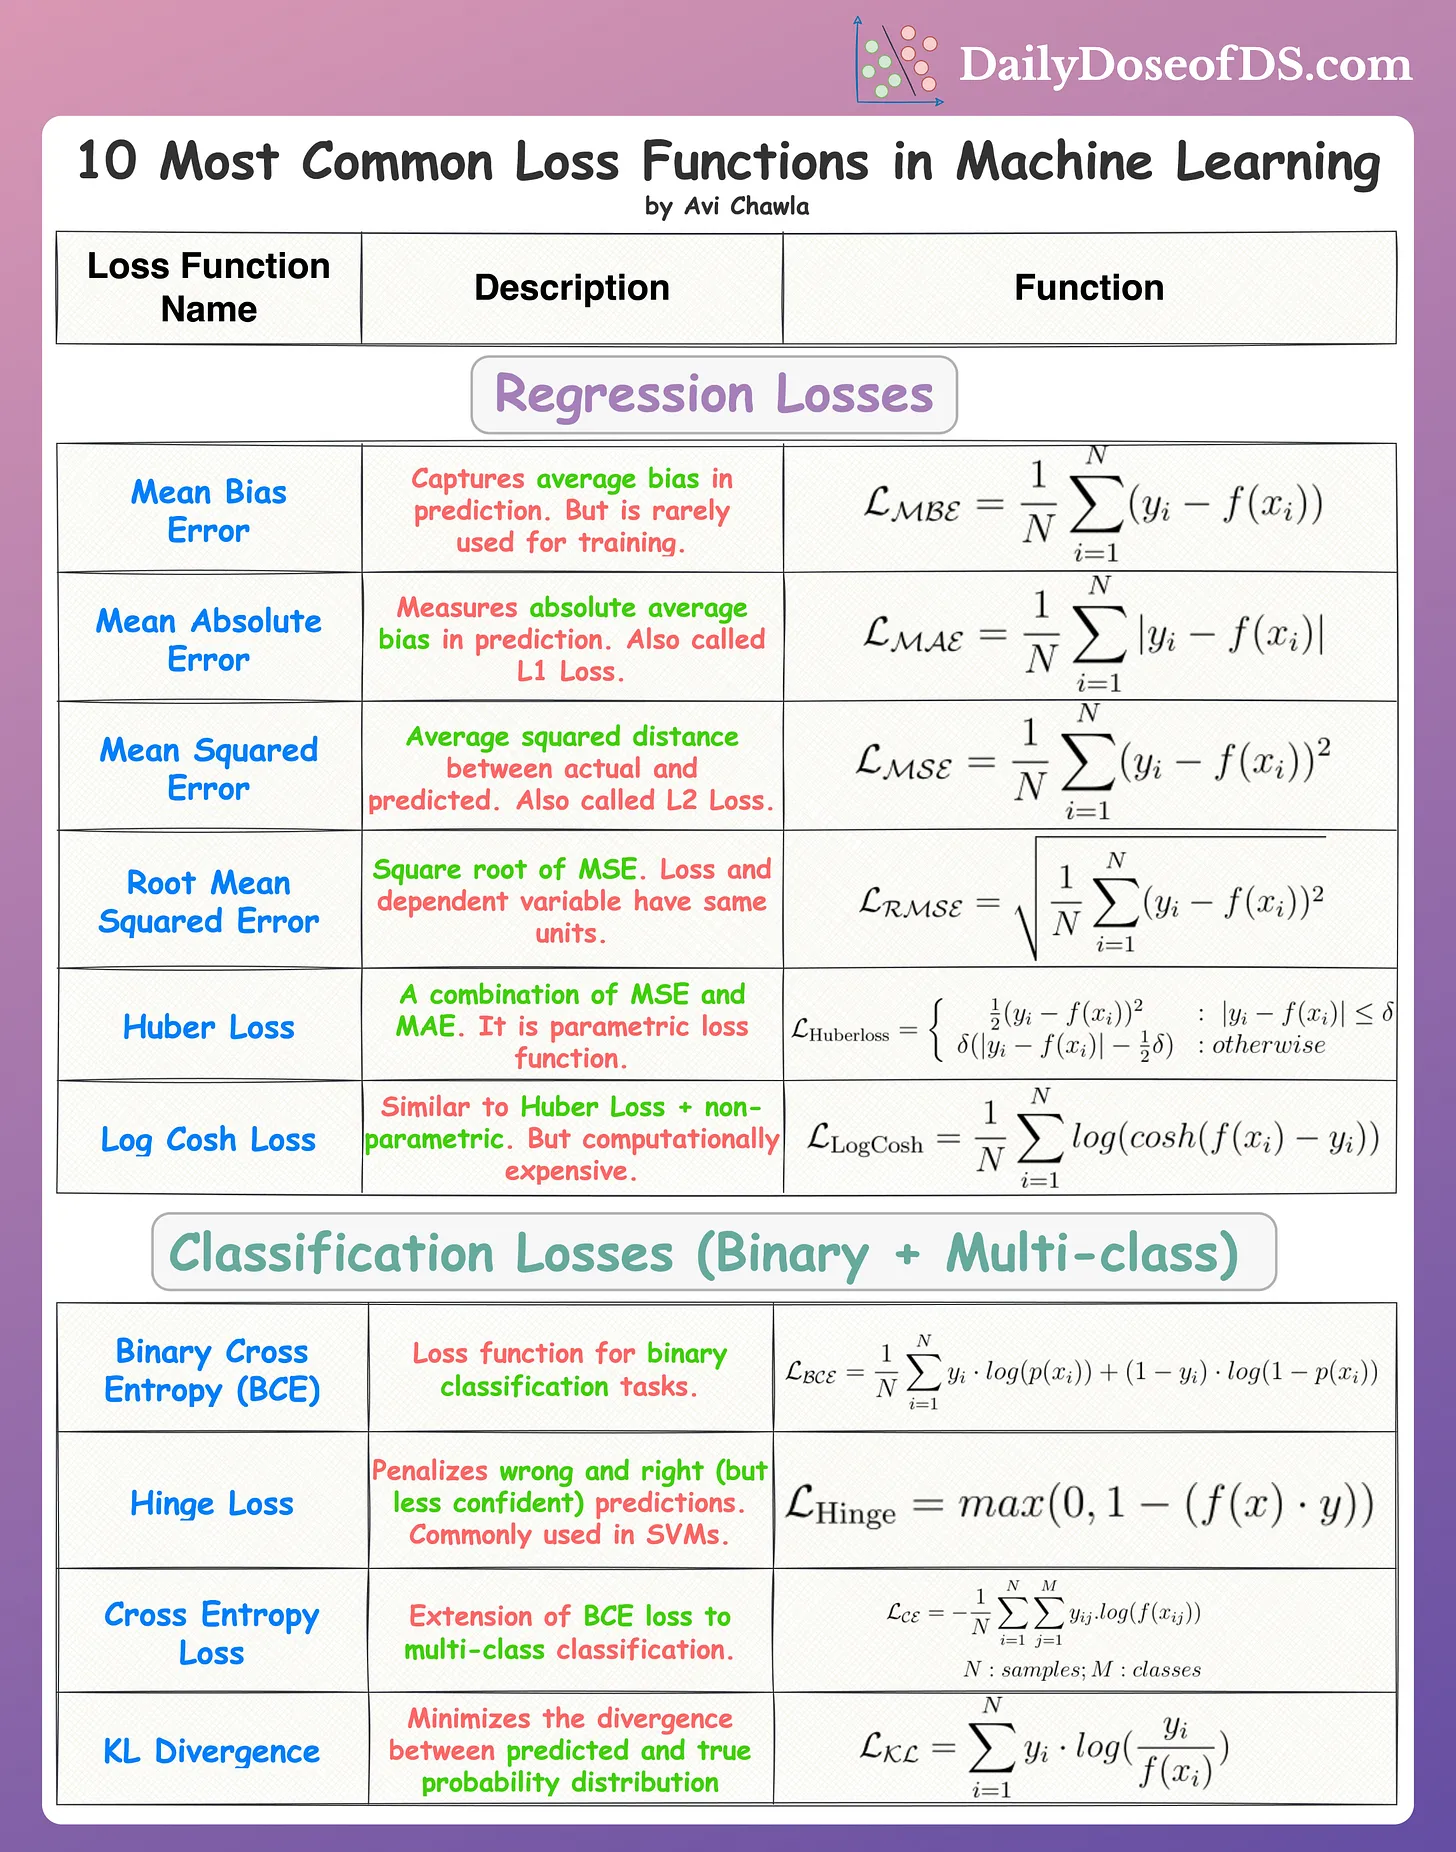

In [30]:
def mse(y_true, y_pred):
    # mean squared error loss
    return np.mean(np.power(y_true - y_pred, 2))

def mse_prime(y_true, y_pred):
    # derivative of mse with respect to predictions
    return 2 * (y_pred - y_true) / np.size(y_true)

def binary_cross_entropy(y_true, y_pred):
    # binary cross-entropy loss
    return np.mean(-y_true * np.log(y_pred) - (1 - y_true) * np.log(1 - y_pred))

def binary_cross_entropy_prime(y_true, y_pred):
    # derivative of binary cross-entropy with respect to predictions
    return ((1 - y_true) / (1 - y_pred) - y_true / y_pred) / np.size(y_true)


In [31]:
class Activation(Layer):
    # base class for activation functions with their derivatives
    def __init__(self, activation, activation_prime):
        self.activation = activation  # activation function
        self.activation_prime = activation_prime  # derivative of activation function

    def forward(self, input):
        self.input = input  # save input for backward pass
        return self.activation(self.input)  # apply activation

    def backward(self, output_gradient, learning_rate):
        # compute gradient of the activation function and propagate backward
        return np.multiply(output_gradient, self.activation_prime(self.input))


In [32]:
class Sigmoid(Activation):
    # sigmoid activation function and its derivative
    def __init__(self):
        def sigmoid(x):
            return 1 / (1 + np.exp(-x))  # sigmoid function

        def sigmoid_prime(x):
            s = sigmoid(x)  # compute sigmoid
            return s * (1 - s)  # derivative of sigmoid

        super().__init__(sigmoid, sigmoid_prime)  # initialize parent class with sigmoid and its derivative


In [33]:
class Softmax(Layer):
    # softmax activation function for multi-class classification
    def forward(self, input):
        tmp = np.exp(input)  # exponentiate input to avoid overflow
        self.output = tmp / np.sum(tmp)  # normalize to get probabilities
        return self.output

    def backward(self, output_gradient, learning_rate):
        n = np.size(self.output)  # get the size of the output
        # compute the gradient of softmax and propagate backward
        return np.dot((np.identity(n) - self.output.T) * self.output, output_gradient)
        # alternative:
        # tmp = np.tile(self.output, n)
        # return np.dot(tmp * (np.identity(n) - np.transpose(tmp)), output_gradient)


In [56]:
def predict(network, input):
    # function to make a prediction using the trained network
    output = input  # initialize output with the input
    for layer in network:  # iterate over layers in the network
        output = layer.forward(output)  # pass the input through each layer's forward method
    return output  # return the final output after all layers


def train(network, loss, loss_prime, x_train, y_train, epochs = 1000, learning_rate = 0.01, verbose = True):
    for e in range(epochs):
        error = 0
        for x, y in zip(x_train, y_train):
            # forward
            output = predict(network, x)

            # error
            error += loss(y, output)

            # backward
            grad = loss_prime(y, output)
            for layer in reversed(network):
                grad = layer.backward(grad, learning_rate)

        error /= len(x_train)
        if verbose:
            print(f"{e + 1}/{epochs}, error={error}")

In [60]:
import matplotlib.pyplot as plt

def data2FeaturesMoreClasses(inputs, outputs, outputNames):
    # Get unique class labels
    labels = set(outputs)

    # Create a figure for plotting
    plt.figure(figsize=(8, 6))

    # Loop through each class label and plot the points corresponding to that class
    for crtLabel in labels:
        # Extract points where the output equals the current class label
        class_points = [inputs[i] for i in range(len(inputs)) if outputs[i] == crtLabel]

        # Extract the first and second feature from the class points for plotting
        x = [point[0] for point in class_points]  # First feature (feat1)
        y = [point[1] for point in class_points]  # Second feature (feat2)

        # Plot the points with a label for the class
        plt.scatter(x, y, label=outputNames[crtLabel])

    # Set axis labels
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')

    # Display legend and plot
    plt.legend()
    plt.show()


In [61]:
import matplotlib.pyplot as plt

def plot_samples(inputs, outputs, outputNames, num_samples=5):
    # Create a subplot grid for displaying the images
    fig, axes = plt.subplots(1, num_samples, figsize=(15, 3))

    # Loop through the number of samples to plot
    for i in range(num_samples):
        ax = axes[i]  # Select each axis in the subplot
        ax.imshow(inputs[i])  # Show the image
        ax.set_title(f"Label: {outputNames[outputs[i]]}")  # Title with class name
        ax.axis('off')  # Turn off axis labels for better display

    plt.tight_layout()  # Adjust layout to avoid overlap
    plt.show()


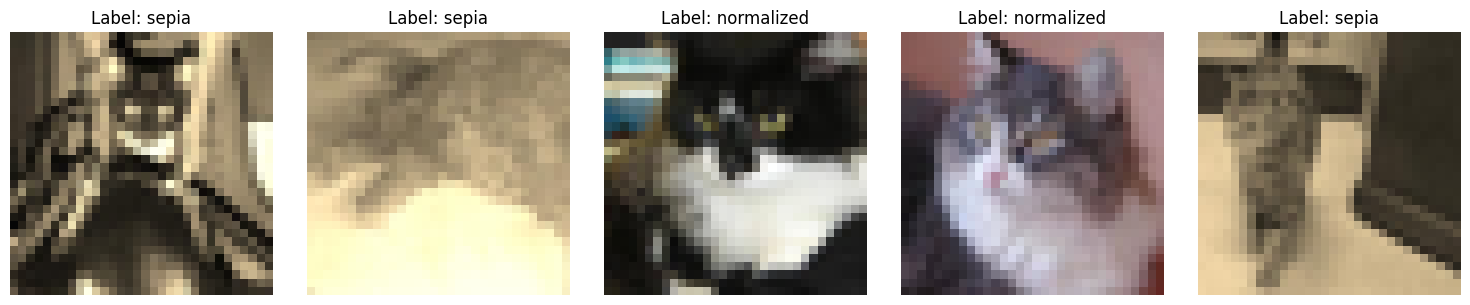

In [63]:
def load_images_from_folder_mixed(folder_path):
    inputs = []
    outputs = []
    outputNames = ['normalized', 'sepia']

    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):  # Process only image files
            label = 1 if '_sepia' in filename.lower() else 0  # Set label based on filename
            img = Image.open(os.path.join(folder_path, filename)).resize((32, 32))  # Resize to 32x32
            img_array = np.array(img) / 255.0  # Normalize pixel values to range [0, 1]
            inputs.append(img_array)  # Add image to inputs
            outputs.append(label)  # Add label to outputs

    # Shuffle data
    noData = len(inputs)
    permutation = np.random.permutation(noData)
    inputs = np.array(inputs)[permutation]
    outputs = np.array(outputs)[permutation]

    return inputs, outputs, outputNames

# Plotting
inputs, outputs, outputNames = load_images_from_folder_mixed('Dataset')
plot_samples(inputs[:5], outputs[:5], outputNames)


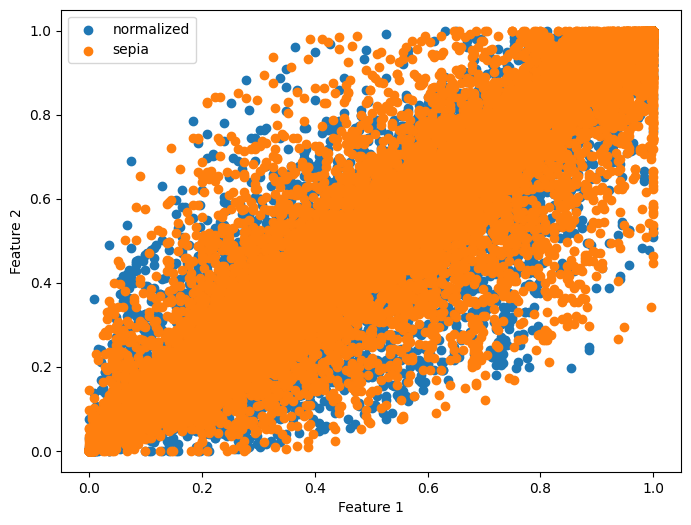

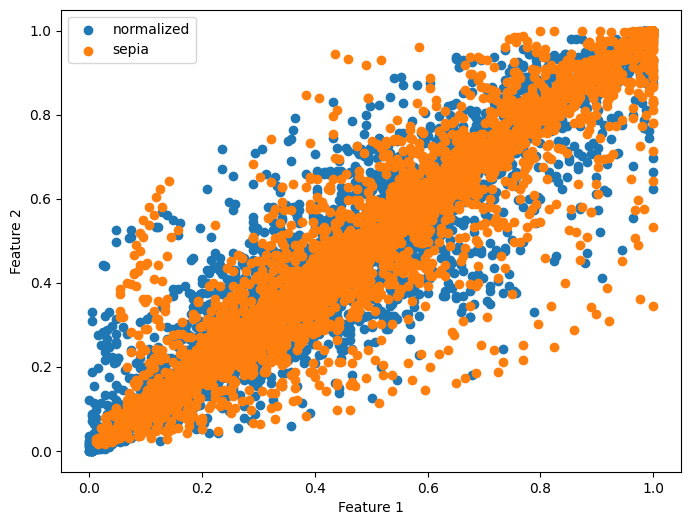

In [68]:
def splitData(input_data, output_data):
    np.random.seed(5)  # For reproducibility
    indexes = [i for i in range(len(input_data))]  # Create list of indexes
    trainSample = np.random.choice(indexes, int(0.8 * len(input_data)), replace=False)  # 80% for training
    testSample = [i for i in indexes if not i in trainSample]  # 20% for testing

    # Split inputs and outputs into training and testing sets
    trainInputs = [input_data[i] for i in trainSample]
    trainOutputs = [output_data[i] for i in trainSample]
    testInputs = [input_data[i] for i in testSample]
    testOutputs = [output_data[i] for i in testSample]

    return trainInputs, trainOutputs, testInputs, testOutputs

# Splitting data
trainInputs, trainOutputs, testInputs, testOutputs = splitData(inputs, outputs)
# Assuming outputNames is defined as:
outputNames = ['normalized', 'sepia']

# Train data visualization
data2FeaturesMoreClasses(trainInputs, trainOutputs, outputNames)

# Test data visualization
data2FeaturesMoreClasses(testInputs, testOutputs, outputNames)



In [64]:
def splitData(input_data, output_data):
    np.random.seed(5)
    indexes = [i for i in range(len(inputs))]
    trainSample = np.random.choice(indexes, int(0.8 * len(inputs)), replace = False)
    testSample = [i for i in indexes  if not i in trainSample]

    trainInputs = [inputs[i] for i in trainSample]
    trainOutputs = [outputs[i] for i in trainSample]
    testInputs = [inputs[i] for i in testSample]
    testOutputs = [outputs[i] for i in testSample]

    return trainInputs, trainOutputs, testInputs, testOutputs

In [65]:
trainInputs, trainOutputs, testInputs, testOutputs = splitData(inputs, outputs)

In [69]:
def normalisation(trainData, testData):
    scaler = StandardScaler()
    if not isinstance(trainData[0], list):
        # encode each sample into a list
        trainData = [[d] for d in trainData]
        testData = [[d] for d in testData]

        scaler.fit(trainData)  # fit only on training data
        normalisedTrainData = scaler.transform(trainData)  # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data

        # decode from list to raw values
        normalisedTrainData = [el[0] for el in normalisedTrainData]
        normalisedTestData = [el[0] for el in normalisedTestData]
    else:
        scaler.fit(trainData)  # fit only on training data
        normalisedTrainData = scaler.transform(trainData)  # apply same transformation to train data
        normalisedTestData = scaler.transform(testData)  # apply same transformation to test data
    return normalisedTrainData, normalisedTestData

def flatten(mat):
    x = []
    for line in mat:
        for el in line:
            x.append(el)
    return x

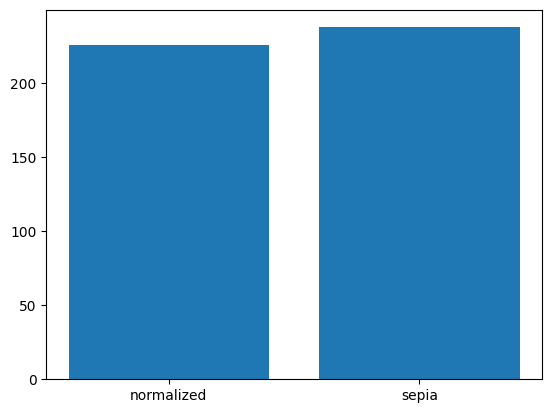

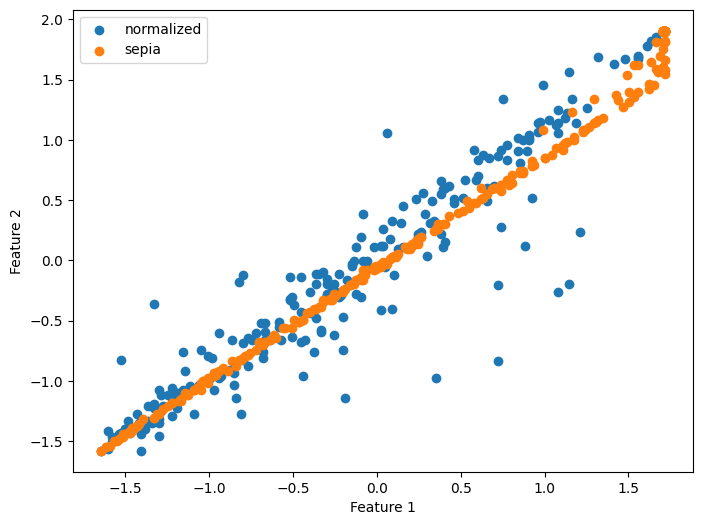

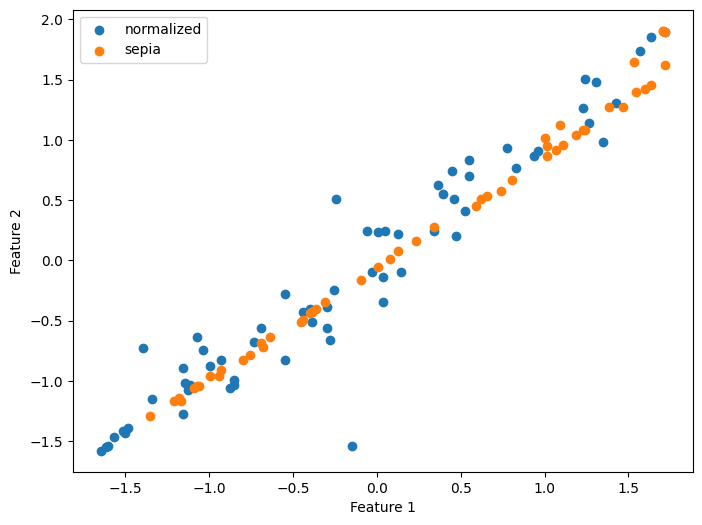

In [72]:
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Define flatten function
def flatten(mat):
    return mat.flatten()  # Flatten the image to a 1D array

# Normalization function
def normalisation(trainData, testData):
    scaler = StandardScaler()
    scaler.fit(trainData)  # fit only on training data
    normalisedTrainData = scaler.transform(trainData)  # apply same transformation to train data
    normalisedTestData = scaler.transform(testData)  # apply same transformation to test data
    return normalisedTrainData, normalisedTestData

# Define the plot for the outputs
bins = range(len(outputNames) + 1)
plt.hist(trainOutputs, bins, rwidth=0.8)
bin_w = (max(bins) - min(bins)) / (len(bins) - 1)
plt.xticks(np.arange(min(bins) + bin_w / 2, max(bins), bin_w), outputNames)
plt.show()

# Flatten the images to 1D arrays
trainInputsFlatten = [flatten(el) for el in trainInputs]
testInputsFlatten = [flatten(el) for el in testInputs]

# Convert the lists to 2D numpy arrays for scaling
trainInputsFlatten = np.array(trainInputsFlatten)
testInputsFlatten = np.array(testInputsFlatten)

# Normalize the inputs
trainInputsNormalised, testInputsNormalised = normalisation(trainInputsFlatten, testInputsFlatten)

# Visualize the normalized data
data2FeaturesMoreClasses(trainInputsNormalised, trainOutputs, outputNames)
data2FeaturesMoreClasses(testInputsNormalised, testOutputs, outputNames)


In [73]:
def plotConfusionMatrix(cm, classNames, title):
    from sklearn.metrics import confusion_matrix
    import itertools

    classes = classNames
    plt.figure()
    plt.imshow(cm, interpolation='nearest', cmap='Blues')
    plt.title('Confusion Matrix ' + title)
    plt.colorbar()
    tick_marks = np.arange(len(classNames))
    plt.xticks(tick_marks, classNames, rotation=45)
    plt.yticks(tick_marks, classNames)

    text_format = 'd'
    thresh = cm.max() / 2.
    for row, column in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(column, row, format(cm[row, column], text_format),
                 horizontalalignment='center',
                color='black')

    plt.ylabel('True label')
    plt.xlabel('Predicted label')
    plt.tight_layout()

    plt.show()

In [74]:
model = [
    Convolutional((1, 8, 8), 3, 5),         # Output: (5, 6, 6)
    Sigmoid(),
    Reshape((5, 6, 6), (5 * 6 * 6, 1)),     # Corect: (180, 1)
    Dense(5 * 6 * 6, 100),
    Sigmoid(),
    Dense(100, 2),
    Sigmoid()
]

In [77]:
from PIL import Image
import numpy as np

# Function to resize images to 8x8 while keeping the 3 color channels
def resize_images(inputs, size=(8, 8)):
    resized_images = []
    for img in inputs:
        pil_img = Image.fromarray(np.uint8(img))  # Convert numpy array to PIL image
        resized_img = pil_img.resize(size)  # Resize the image to 8x8
        resized_images.append(np.array(resized_img))  # Convert it back to numpy array
    return np.array(resized_images)

# Resize the images
trainInputsResized = resize_images(trainInputs, size=(8, 8))
testInputsResized = resize_images(testInputs, size=(8, 8))

# Now reshape each image to (3, 8, 8) for CNN
trainInputsCNN = [np.reshape(im, (3, 8, 8)) for im in trainInputsResized]
testInputsCNN = [np.reshape(im, (3, 8, 8)) for im in testInputsResized]

# Check the shape of the first image in the train set
print(trainInputsCNN[0].shape)  # Should be (3, 8, 8)


(3, 8, 8)


In [78]:
train(
    model,
    binary_cross_entropy,
    binary_cross_entropy_prime,
    trainInputsCNN,
    trainOutputs,
    epochs=200,
    learning_rate=0.01
)

1/200, error=0.8122771599547294
2/200, error=0.69291792090985
3/200, error=0.6846128517295107
4/200, error=0.6799043413403691
5/200, error=0.6765759531652591
6/200, error=0.6739700809831066
7/200, error=0.6719173258729031
8/200, error=0.6702947414973721
9/200, error=0.6689464935055082
10/200, error=0.6677684270534836
11/200, error=0.6667085204288024
12/200, error=0.6657377823846192
13/200, error=0.6648365188795324
14/200, error=0.6639900751371823
15/200, error=0.6631875442301115
16/200, error=0.6624212867072444
17/200, error=0.6616867251433199
18/200, error=0.6609821454212389
19/200, error=0.6603080674931927
20/200, error=0.6596657653270327
21/200, error=0.6590552418083779
22/200, error=0.6584739753290654
23/200, error=0.6579174772027301
24/200, error=0.6573809858962143
25/200, error=0.6568607668681821
26/200, error=0.6563543919459088
27/200, error=0.6558603957522606
28/200, error=0.6553778390662955
29/200, error=0.6549060077500705
30/200, error=0.6544442569847218
31/200, error=0.65399

In [79]:
predictions = [np.argmax(predict(model, x)) for x in testInputsCNN]

accuracy = np.mean(np.array(predictions) == np.array(testOutputs))
print("Acuratețea pe setul de test:", accuracy)

Acuratețea pe setul de test: 0.6206896551724138
